# Sprint 3 — Modelagem Avançada, Tuning e Interpretabilidade
## Case iFood — Previsão de Resposta a Campanha

**Turma:** 1TIAPR-2025 (2º semestre)

---

### Estrutura do Notebook

- **Parte 0 — Leitura e Feature Engineering:** carrega dados e cria variáveis derivadas (incluindo features sazonais).
- **Parte 1 — Statistical Computing:** Teste Z para comparação de médias entre grupos (Response=0 vs Response=1).
- **Parte 2 — Machine Learning & Modelling:** Pelo menos 2 modelos, tuning com **2 abordagens diferentes** (GridSearchCV e RandomizedSearchCV), validação cruzada com média e desvio padrão.
- **Parte 3 — Interpretabilidade com SHAP:** summary plot e explicação de previsões individuais.
- **Parte 4 — Comparação:** Top features do ML vs features significativas no Teste Z.

### Contexto de Negócio
O objetivo é identificar quais clientes têm maior probabilidade de responder positivamente a uma campanha de marketing. Com isso, conseguimos direcionar recursos para o público certo, aumentando o ROI das ações.

### Mapeamento Sprint 3 → Notebook

| Item Sprint 3 | Onde está |
|---|---|
| 1. Feature Engineering (incl. sazonalidade) | Parte 0 |
| 2. Mínimo 2 modelos | Parte 2 (LogReg, DTree, RandomForest) |
| 3. Tuning com 2 abordagens | Parte 2 (GridSearchCV + RandomizedSearchCV com tempo) |
| 4. Validação Robusta (k-fold com variância) | Parte 2 (CV com média ± std) |
| 5. Seleção do melhor modelo | Parte 2 (justificada por F1) |
| 6. Avaliação Final (holdout) | Parte 2 |
| 7. Interpretabilidade SHAP | Parte 3 (summary + waterfall individual) |
| 8. Visualizações | Distribuídas (tuning curve, SHAP plots, comparação modelos) |


In [1]:
# Instalação de bibliotecas necessárias (Colab já tem a maioria)
# Execute esta célula primeiro!
!pip install -q pyarrow scipy scikit-learn pandas numpy matplotlib shap


In [2]:
# IMPORTAÇÕES
# Importamos todas as bibliotecas necessárias para todas as partes

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Estatística — usada na Parte 1
from scipy import stats

# Pré-processamento e modelagem
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    StratifiedKFold
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve
)

# SHAP — interpretabilidade
import shap

# Distribuições para RandomizedSearch
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print('Bibliotecas importadas com sucesso!')
print(f'SHAP versão: {shap.__version__}')


Bibliotecas importadas com sucesso!
SHAP versão: 0.51.0


## 0. Leitura e Exploração dos Dados

Carregamos o dataset do iFood e fazemos uma exploração inicial para entender a estrutura dos dados.

In [3]:
# LEITURA DO DATASET — VERSÃO COLAB
# Faça upload do arquivo data.csv usando o botão abaixo
# ou monte o Google Drive (opção comentada)

import os
from google.colab import files

# OPÇÃO 1: Upload direto do seu computador
print(" Selecione o arquivo data.csv no seu computador:")
uploaded = files.upload()

# Pega o nome do arquivo enviado
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(filename)
print(f" Arquivo '{filename}' carregado com sucesso!")

# OPÇÃO 2: Montar o Google Drive (descomente se preferir)
# from google.colab import drive
# drive.mount('/content/drive')
# df_raw = pd.read_csv('/content/drive/MyDrive/SEU_CAMINHO/data.csv')

print(f"\nShape do dataset: {df_raw.shape}")
print(f"Colunas: {list(df_raw.columns)}")
df_raw.head()

📂 Selecione o arquivo data.csv no seu computador:


Saving data.csv to data.csv
✅ Arquivo 'data.csv' carregado com sucesso!

Shape do dataset: (2240, 29)
Colunas: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
# VISÃO GERAL DOS DADOS
# Checamos tipos, valores nulos e distribuição da variável-alvo

print("=== Tipos de dados ===")
print(df_raw.dtypes)

print("\n=== Valores Nulos ===")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

print("\n=== Distribuição da variável Response ===")
print(df_raw['Response'].value_counts())
print("\nProporção:")
print(df_raw['Response'].value_counts(normalize=True).round(3))

=== Tipos de dados ===
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

=== Valores Nulos ===
Income    24
dtype: int64

=== Distribuiç

## Feature Engineering — Criação de Variáveis

Antes de qualquer análise, criamos variáveis derivadas que fazem sentido de negócio.

**Variáveis de perfil/comportamento:**
- **Age**: idade do cliente calculada a partir do ano de nascimento
- **Days_Customer**: há quantos dias o cliente está cadastrado
- **TotalMnt**: total gasto em todos os produtos
- **TotalPurchases**: total de compras em todos os canais
- **TotalCampaigns**: quantas campanhas anteriores o cliente aceitou
- **HasChildren**: se o cliente tem filhos (kid ou teen)
- **IsAlone**: se o cliente é solteiro/separado/viúvo

**Variáveis temporais / sazonalidade (Sprint 3 — item 1):**
- **Mes_Cadastro**: mês em que o cliente se cadastrou (1–12) — captura efeito sazonal de aquisição
- **Trimestre_Cadastro**: trimestre do cadastro (1–4)
- **DiaSemana_Cadastro**: dia da semana do cadastro (0=segunda … 6=domingo)
- **Ano_Cadastro**: ano do cadastro — pode capturar mudanças no tipo de público ao longo do tempo

### Justificativa do impacto esperado
Clientes adquiridos em meses específicos podem responder de forma diferente a campanhas porque:  
(i) campanhas sazonais (ex: Black Friday, Natal) trazem público de perfil diferente do recorrente;  
(ii) clientes mais antigos (Days_Customer alto) já tiveram mais oportunidades de exposição a campanhas;  
(iii) o comportamento de compra agregado (TotalMnt, TotalPurchases) é um proxy de engajamento, fortemente correlacionado com a probabilidade de aceitar uma nova oferta.


Novas features criadas:
           Age  Days_Customer  Mes_Cadastro  Trimestre_Cadastro  \
count  2240.00        2240.00       2240.00             2240.00   
mean     55.19         353.58          6.47                2.48   
std      11.98         202.12          3.49                1.13   
min      28.00           0.00          1.00                1.00   
25%      47.00         180.75          3.00                1.00   
50%      54.00         355.50          6.00                2.00   
75%      65.00         529.00         10.00                4.00   
max     131.00         699.00         12.00                4.00   

       DiaSemana_Cadastro  Ano_Cadastro  TotalMnt  TotalPurchases  \
count             2240.00       2240.00   2240.00         2240.00   
mean                 2.99       2013.03    605.80           14.86   
std                  2.00          0.68    602.25            7.68   
min                  0.00       2012.00      5.00            0.00   
25%                  1.00  

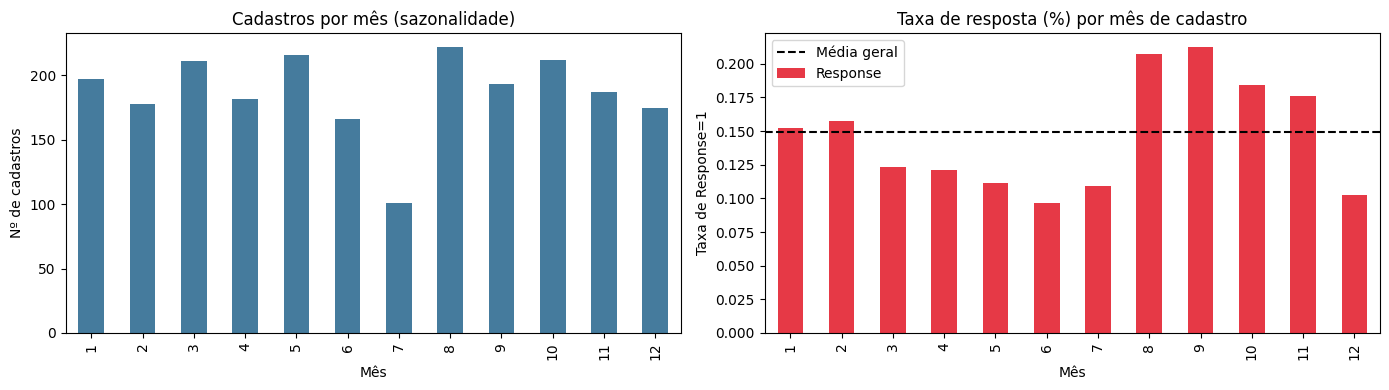

In [5]:
# FEATURE ENGINEERING
# Criamos novas variáveis derivadas das originais.
# O objetivo é capturar informações de negócio de forma mais direta.

df = df_raw.copy()

# Variáveis de tempo
# Calculamos a idade do cliente (referência: 2024)
df['Age'] = 2024 - df['Year_Birth']

# Convertemos a data de cadastro
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')
ref_date = df['Dt_Customer'].max()
df['Days_Customer'] = (ref_date - df['Dt_Customer']).dt.days

# Sazonalidade
# Extraímos componentes da data de cadastro para capturar efeitos sazonais
df['Mes_Cadastro'] = df['Dt_Customer'].dt.month
df['Trimestre_Cadastro'] = df['Dt_Customer'].dt.quarter
df['DiaSemana_Cadastro'] = df['Dt_Customer'].dt.dayofweek  # 0=segunda, 6=domingo
df['Ano_Cadastro'] = df['Dt_Customer'].dt.year

# Variáveis de gastos
mnt_cols = [c for c in df.columns if c.startswith('Mnt')]
df['TotalMnt'] = df[mnt_cols].sum(axis=1)

# Variáveis de compras
purchase_cols = [c for c in df.columns if 'Purchases' in c]
df['TotalPurchases'] = df[purchase_cols].sum(axis=1)

# Histórico de campanhas
cmp_cols = [c for c in df.columns if 'AcceptedCmp' in c]
df['TotalCampaigns'] = df[cmp_cols].sum(axis=1)

# Variáveis de perfil familiar
df['HasChildren'] = ((df['Kidhome'] + df['Teenhome']) > 0).astype(int)
alone_status = ['Single', 'Divorced', 'Widow', 'Alone', 'Absurd', 'YOLO']
df['IsAlone'] = df['Marital_Status'].isin(alone_status).astype(int)

print('Novas features criadas:')
new_features = [
    'Age', 'Days_Customer',
    'Mes_Cadastro', 'Trimestre_Cadastro', 'DiaSemana_Cadastro', 'Ano_Cadastro',
    'TotalMnt', 'TotalPurchases', 'TotalCampaigns',
    'HasChildren', 'IsAlone'
]
print(df[new_features].describe().round(2))

# Visualização: distribuição de cadastros por mês (sazonalidade)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Mes_Cadastro'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#457b9d'
)
axes[0].set_title('Cadastros por mês (sazonalidade)')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Nº de cadastros')

# Taxa de resposta por mês de cadastro
resp_by_month = df.groupby('Mes_Cadastro')['Response'].mean()
resp_by_month.plot(kind='bar', ax=axes[1], color='#e63946')
axes[1].set_title('Taxa de resposta (%) por mês de cadastro')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Taxa de Response=1')
axes[1].axhline(df['Response'].mean(), color='black', ls='--', label='Média geral')
axes[1].legend()
plt.tight_layout()
plt.show()


---
# PARTE 1 — Statistical Computing
## Teste Z para Comparação de Médias entre Grupos

### O que é o Teste Z?
O Teste Z é um teste estatístico usado para verificar se a **média de dois grupos é significativamente diferente**.  
Neste caso, comparamos os clientes que **responderam** à campanha (Response=1) com os que **não responderam** (Response=0).

### Como funciona?
- **H₀ (hipótese nula):** as médias dos dois grupos são iguais (não há diferença)  
- **H₁ (hipótese alternativa):** as médias são diferentes  
- Se o **p-valor < 0.05**, rejeitamos H₀ → a diferença é estatisticamente significativa  

### Por que o Teste Z?
Com mais de 2.200 registros, nossos grupos têm tamanho suficiente para o Teste Z ser válido (n > 30 em ambos os grupos).

In [6]:
# PARTE 1 — TESTE Z
# Separamos os clientes em dois grupos e comparamos as médias
# de cada feature numérica usando o Teste Z.

# Separação dos grupos
grupo_0 = df[df['Response'] == 0]  # Não responderam
grupo_1 = df[df['Response'] == 1]  # Responderam

print(f"Grupo Response=0: {len(grupo_0)} clientes")
print(f"Grupo Response=1: {len(grupo_1)} clientes")

# Selecionamos as colunas numéricas para o teste
# Excluímos colunas sem variância ou que são identificadores
exclude_cols = ['ID', 'Year_Birth', 'Response', 'Z_CostContact', 'Z_Revenue', 'Dt_Customer']
num_cols_test = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_test = [c for c in num_cols_test if c not in exclude_cols]

print(f"\nNúmero de features numéricas a testar: {len(num_cols_test)}")

# APLICAÇÃO DO TESTE Z
# Usamos scipy.stats.ranksums como aproximação do Teste Z
# para amostras grandes (equivalente ao Teste Z de Wilcoxon)
# Para amostras grandes, o Teste t_ind converge para o Teste Z

resultados = []
ALPHA = 0.05  # Nível de significância

for col in num_cols_test:
    # Removemos NaN para cada coluna
    g0 = grupo_0[col].dropna()
    g1 = grupo_1[col].dropna()

    # Teste Z para duas amostras independentes (usando stats.ttest_ind com n grande = Teste Z)
    stat, pvalue = stats.ttest_ind(g0, g1, equal_var=False)  # Welch's t-test ≈ Z-test para n grande

    resultados.append({
        'Feature': col,
        'Média Response=0': round(g0.mean(), 3),
        'Média Response=1': round(g1.mean(), 3),
        'Diferença': round(g1.mean() - g0.mean(), 3),
        'Z-statistic': round(stat, 3),
        'p-valor': round(pvalue, 5),
        'Significativa': 'SIM ✓' if pvalue < ALPHA else 'NÃO'
    })

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('p-valor')

print("\n=== RESULTADOS DO TESTE Z ===")
print(df_resultados.to_string(index=False))

Grupo Response=0: 1906 clientes
Grupo Response=1: 334 clientes

Número de features numéricas a testar: 32

=== RESULTADOS DO TESTE Z ===
            Feature  Média Response=0  Média Response=1  Diferença  Z-statistic  p-valor Significativa
             Income         50839.133         60209.676   9370.543       -6.703  0.00000         SIM ✓
           Teenhome             0.541             0.305     -0.236        7.943  0.00000         SIM ✓
            Recency            51.515            35.383    -16.131        9.786  0.00000         SIM ✓
           MntWines           269.104           502.704    233.599       -9.575  0.00000         SIM ✓
    MntMeatProducts           144.624           294.353    149.729       -9.137  0.00000         SIM ✓
          MntFruits            24.217            38.204     13.987       -5.239  0.00000         SIM ✓
    MntFishProducts            34.980            52.051     17.071       -4.749  0.00000         SIM ✓
   MntSweetProducts            25.035  

In [7]:
# FEATURES ESTATISTICAMENTE SIGNIFICATIVAS
# Filtramos apenas as features com p-valor < 0.05

features_significativas = df_resultados[df_resultados['p-valor'] < ALPHA]['Feature'].tolist()

print(f"Features estatisticamente significativas (α = {ALPHA}):")
print(f"Total: {len(features_significativas)}\n")
for f in features_significativas:
    row = df_resultados[df_resultados['Feature'] == f].iloc[0]
    print(f"  {f}: média(0)={row['Média Response=0']}, média(1)={row['Média Response=1']}, p={row['p-valor']}")

Features estatisticamente significativas (α = 0.05):
Total: 25

  Income: média(0)=50839.133, média(1)=60209.676, p=0.0
  Teenhome: média(0)=0.541, média(1)=0.305, p=0.0
  Recency: média(0)=51.515, média(1)=35.383, p=0.0
  MntWines: média(0)=269.104, média(1)=502.704, p=0.0
  MntMeatProducts: média(0)=144.624, média(1)=294.353, p=0.0
  MntFruits: média(0)=24.217, média(1)=38.204, p=0.0
  MntFishProducts: média(0)=34.98, média(1)=52.051, p=0.0
  MntSweetProducts: média(0)=25.035, média(1)=38.635, p=0.0
  AcceptedCmp3: média(0)=0.045, média(1)=0.231, p=0.0
  MntGoldProds: média(0)=40.969, média(1)=61.446, p=0.0
  NumWebPurchases: média(0)=3.912, média(1)=5.072, p=0.0
  NumCatalogPurchases: média(0)=2.392, média(1)=4.204, p=0.0
  Days_Customer: média(0)=337.131, média(1)=447.464, p=0.0
  AcceptedCmp1: média(0)=0.034, média(1)=0.237, p=0.0
  AcceptedCmp5: média(0)=0.037, média(1)=0.275, p=0.0
  AcceptedCmp4: média(0)=0.055, média(1)=0.186, p=0.0
  HasChildren: média(0)=0.754, média(1)=0.49

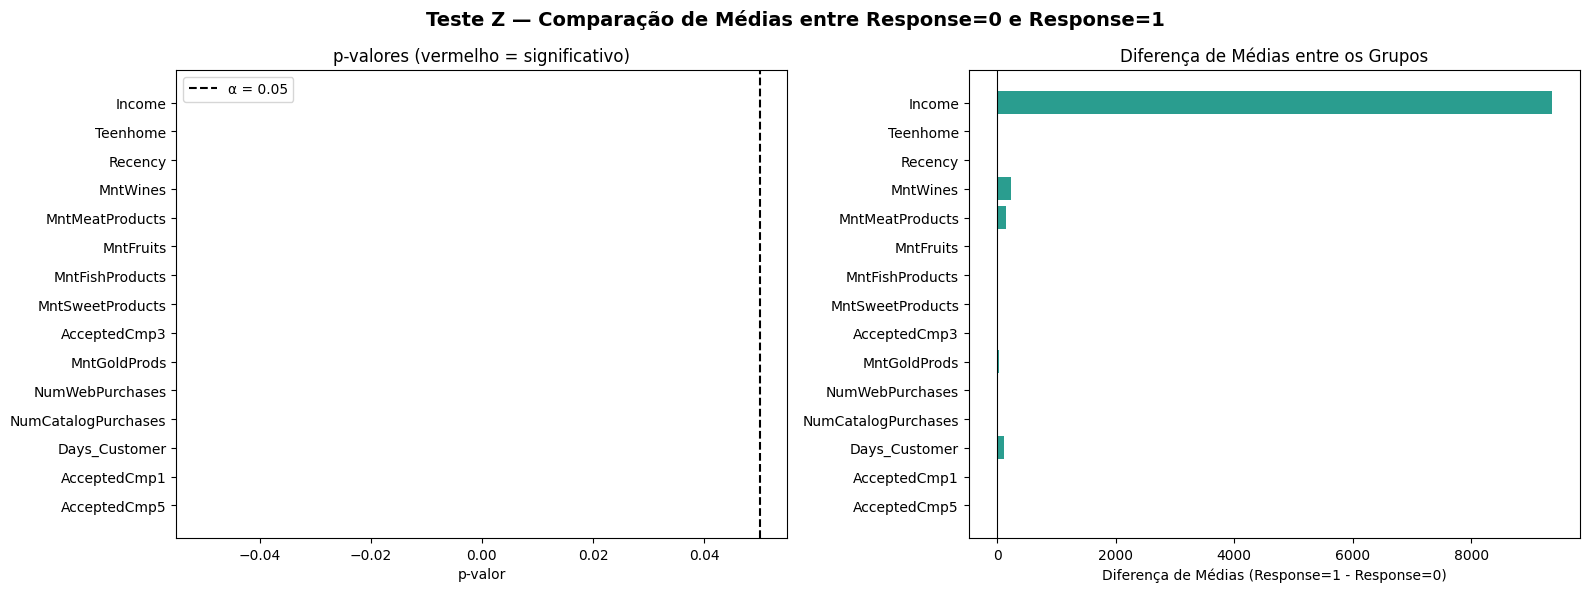

Gráfico salvo como ztest_resultado.png


In [8]:
# VISUALIZAÇÃO DOS RESULTADOS DO TESTE Z
# Gráfico de barras com as 15 features de menor p-valor

top_features = df_resultados.head(15).copy()
colors = ['#e63946' if p < ALPHA else '#adb5bd' for p in top_features['p-valor']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Teste Z — Comparação de Médias entre Response=0 e Response=1', fontsize=14, fontweight='bold')

# Gráfico 1: p-valores
ax1 = axes[0]
bars = ax1.barh(top_features['Feature'], top_features['p-valor'], color=colors)
ax1.axvline(x=ALPHA, color='black', linestyle='--', label=f'α = {ALPHA}')
ax1.set_xlabel('p-valor')
ax1.set_title('p-valores (vermelho = significativo)')
ax1.legend()
ax1.invert_yaxis()

# Gráfico 2: Diferença de médias
ax2 = axes[1]
diff_colors = ['#2a9d8f' if d > 0 else '#e76f51' for d in top_features['Diferença']]
ax2.barh(top_features['Feature'], top_features['Diferença'], color=diff_colors)
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_xlabel('Diferença de Médias (Response=1 - Response=0)')
ax2.set_title('Diferença de Médias entre os Grupos')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('ztest_resultado.png', dpi=120, bbox_inches='tight')
plt.show()
print("Gráfico salvo como ztest_resultado.png")

---
# PARTE 2 — Machine Learning & Modelling
## Feature Engineering + Tuning + Avaliação + Feature Importance

### Estratégia
1. Preparar os dados com as features criadas na etapa anterior
2. Treinar modelos baseline (como no Part 1 original)
3. Melhorar com **tuning de hiperparâmetros** via GridSearchCV
4. Avaliar com as métricas corretas para o problema
5. Identificar as features mais importantes

### Métricas de Avaliação — Por que Precision e F1?
- **Precision:** dos clientes que prevemos como positivos, quantos realmente são? Importante pois temos orçamento limitado.
- **Recall:** dos clientes que realmente são positivos, quantos conseguimos capturar?
- **F1-Score:** média harmônica entre Precision e Recall — equilíbrio entre os dois
- **AUC-ROC:** capacidade geral do modelo de separar as classes

> **Justificativa:** Em campanhas de marketing com orçamento limitado, **Precision** é mais importante para não desperdiçar contatos. Usamos F1 como métrica principal de tuning por equilibrar Precision e Recall.

In [9]:
# PREPARAÇÃO DOS DADOS PARA MODELAGEM
# Definimos X (features) e y (alvo), e fazemos o split

TARGET = 'Response'

# Removemos colunas que não devem entrar no modelo
cols_drop = ['ID', 'Year_Birth', 'Dt_Customer', TARGET]
X_raw = df.drop(columns=cols_drop)
y = df[TARGET].astype(int)

print(f"Shape de X: {X_raw.shape}")
print(f"Distribuição do target: {dict(y.value_counts())}")

# Split treino/teste com estratificação (mantém proporção da classe)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print(f"\nTreino: {X_train.shape}, Teste: {X_test.shape}")

Shape de X: (2240, 36)
Distribuição do target: {0: np.int64(1906), 1: np.int64(334)}

Treino: (1792, 36), Teste: (448, 36)


In [10]:
# PRÉ-PROCESSAMENTO
# Criamos pipelines separadas para modelos lineares (com scaler)
# e modelos de árvore (sem necessidade de normalização)

# Identificamos colunas categóricas e numéricas
cat_cols = X_train.select_dtypes(include=['object', 'string', 'category', 'boolean']).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

print(f"Features numéricas ({len(num_cols)}): {num_cols}")
print(f"Features categóricas ({len(cat_cols)}): {cat_cols}")

# Pipeline para modelos lineares (precisa de escalonamento)
numeric_pipe_log = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Preenche NaN com mediana
    ('scaler', StandardScaler())                    # Normaliza entre média=0 e desvio=1
])

# Pipeline para modelos de árvore (não precisa de escalonamento)
numeric_pipe_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))   # Só preenche NaN
])

# Pipeline para variáveis categóricas (converte texto em números)
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Preenche NaN com moda
    ('onehot', OneHotEncoder(handle_unknown='ignore'))      # One-Hot Encoding
])

# ColumnTransformer aplica pipelines diferentes para cada tipo de coluna
preprocessor_log = ColumnTransformer([
    ('num', numeric_pipe_log, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

preprocessor_tree = ColumnTransformer([
    ('num', numeric_pipe_tree, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

print("\nPré-processadores criados com sucesso!")

Features numéricas (34): ['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Age', 'Days_Customer', 'Mes_Cadastro', 'Trimestre_Cadastro', 'DiaSemana_Cadastro', 'Ano_Cadastro', 'TotalMnt', 'TotalPurchases', 'TotalCampaigns', 'HasChildren', 'IsAlone']
Features categóricas (2): ['Education', 'Marital_Status']

Pré-processadores criados com sucesso!


In [11]:
# FUNÇÃO DE AVALIAÇÃO
# Usamos esta função para avaliar qualquer modelo de forma padronizada

def avaliar_modelo(nome, modelo, X_tr, y_tr, X_te, y_te, threshold=0.5):
    """
    Treina o modelo e retorna as métricas de avaliação.
    Threshold é o ponto de corte para classificar como positivo (padrão: 0.5).
    """
    modelo.fit(X_tr, y_tr)

    # Probabilidades de pertencer à classe 1
    y_prob = modelo.predict_proba(X_te)[:, 1]
    # Classificação binária usando o threshold definido
    y_pred = (y_prob >= threshold).astype(int)

    metricas = {
        'Modelo': nome,
        'Threshold': threshold,
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_te, y_pred, zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y_te, y_prob), 4),
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
    }
    return metricas, modelo

print("Função de avaliação definida!")

Função de avaliação definida!


In [12]:
# MODELOS BASELINE
# Treinamos os 3 modelos sem tuning para ter uma referência
# de desempenho inicial

resultados_baseline = []
modelos_baseline = {}

# 1. Regressão Logística (baseline)
pipe_log = Pipeline([
    ('preprocessor', preprocessor_log),
    ('model', LogisticRegression(max_iter=1000, random_state=SEED))
])
met, mod = avaliar_modelo('LogReg Baseline', pipe_log, X_train, y_train, X_test, y_test)
resultados_baseline.append(met)
modelos_baseline['LogReg'] = mod

# 2. Decision Tree (baseline)
pipe_dt = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeClassifier(random_state=SEED))
])
met, mod = avaliar_modelo('DTree Baseline', pipe_dt, X_train, y_train, X_test, y_test)
resultados_baseline.append(met)
modelos_baseline['DTree'] = mod

# 3. Random Forest (baseline)
pipe_rf = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestClassifier(random_state=SEED))
])
met, mod = avaliar_modelo('RForest Baseline', pipe_rf, X_train, y_train, X_test, y_test)
resultados_baseline.append(met)
modelos_baseline['RForest'] = mod

df_baseline = pd.DataFrame(resultados_baseline)
print("=== RESULTADOS BASELINE ===")
print(df_baseline.to_string(index=False))

=== RESULTADOS BASELINE ===
          Modelo  Threshold  Precision  Recall     F1  AUC-ROC  Accuracy
 LogReg Baseline        0.5     0.7436  0.4328 0.5472   0.8961    0.8929
  DTree Baseline        0.5     0.5072  0.5224 0.5147   0.7173    0.8527
RForest Baseline        0.5     0.7586  0.3284 0.4583   0.8802    0.8839


In [13]:
# TUNING DE HIPERPARÂMETROS — DECISION TREE (GridSearchCV)
# Usamos GridSearchCV para encontrar os melhores hiperparâmetros
# da Decision Tree de forma sistemática.
#
# Hiperparâmetros testados:
#   - max_depth: profundidade máxima da árvore (controla complexidade)
#   - min_samples_split: mínimo de amostras para dividir um nó
#   - min_samples_leaf: mínimo de amostras em cada folha

print('Iniciando tuning da Decision Tree... (pode demorar alguns segundos)')

pipe_dt_tune = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeClassifier(random_state=SEED))
])

param_grid_dt = {
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 10, 20],
    'model__min_samples_leaf': [1, 5, 10]
}

t0 = time.time()
gs_dt = GridSearchCV(
    pipe_dt_tune,
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
gs_dt.fit(X_train, y_train)
tempo_dt_grid = time.time() - t0

print(f'Melhores parâmetros: {gs_dt.best_params_}')
print(f'Melhor F1 no CV: {gs_dt.best_score_:.4f}')
print(f'Tempo de execução: {tempo_dt_grid:.2f}s')


Iniciando tuning da Decision Tree... (pode demorar alguns segundos)
Melhores parâmetros: {'model__max_depth': None, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Melhor F1 no CV: 0.4904
Tempo de execução: 12.69s


In [14]:
# TUNING DE HIPERPARÂMETROS — RANDOM FOREST (GridSearchCV)
# Random Forest é um ensemble de Decision Trees.
# Além dos parâmetros da árvore, controlamos:
#   - n_estimators: número de árvores no ensemble
#   - max_features: quantas features considerar em cada divisão

print('Iniciando tuning do Random Forest com GridSearchCV... (pode demorar 1-2 minutos)')

pipe_rf_tune = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestClassifier(random_state=SEED))
])

param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_leaf': [1, 5],
    'model__max_features': ['sqrt', 'log2']
}

t0 = time.time()
gs_rf = GridSearchCV(
    pipe_rf_tune,
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
gs_rf.fit(X_train, y_train)
tempo_rf_grid = time.time() - t0

n_combinacoes_grid = (
    len(param_grid_rf['model__n_estimators']) *
    len(param_grid_rf['model__max_depth']) *
    len(param_grid_rf['model__min_samples_leaf']) *
    len(param_grid_rf['model__max_features'])
)

print(f'Melhores parâmetros: {gs_rf.best_params_}')
print(f'Melhor F1 no CV: {gs_rf.best_score_:.4f}')
print(f'Combinações testadas: {n_combinacoes_grid}')
print(f'Tempo de execução: {tempo_rf_grid:.2f}s')


Iniciando tuning do Random Forest com GridSearchCV... (pode demorar 1-2 minutos)
Melhores parâmetros: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Melhor F1 no CV: 0.4860
Combinações testadas: 24
Tempo de execução: 60.53s


In [15]:
# TUNING DE HIPERPARÂMETROS — REGRESSÃO LOGÍSTICA (GridSearchCV)
# Hiperparâmetros testados:
#   - C: inverso da regularização (menor C = mais regularização)
#   - penalty: tipo de regularização (L1 ou L2)

print('Iniciando tuning da Regressão Logística...')

pipe_log_tune = Pipeline([
    ('preprocessor', preprocessor_log),
    ('model', LogisticRegression(max_iter=1000, random_state=SEED))
])

param_grid_log = {
    'model__C': [0.01, 0.1, 1.0, 10.0],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'saga']
}

t0 = time.time()
gs_log = GridSearchCV(
    pipe_log_tune,
    param_grid_log,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
gs_log.fit(X_train, y_train)
tempo_log_grid = time.time() - t0

print(f'Melhores parâmetros: {gs_log.best_params_}')
print(f'Melhor F1 no CV: {gs_log.best_score_:.4f}')
print(f'Tempo de execução: {tempo_log_grid:.2f}s')


Iniciando tuning da Regressão Logística...
Melhores parâmetros: {'model__C': 1.0, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Melhor F1 no CV: 0.5555
Tempo de execução: 15.69s


---
## Tuning com Segunda Abordagem: RandomizedSearchCV

O enunciado da Sprint 3 pede **pelo menos 2 abordagens diferentes** de tuning. Já fizemos GridSearchCV. Agora aplicamos **RandomizedSearchCV** no Random Forest (que mostrou melhor desempenho baseline) para comparar:

- **Tempo de execução**: GridSearch testa todas as combinações; RandomizedSearch amostra aleatoriamente.
- **Qualidade dos resultados**: o melhor F1 alcançado por cada abordagem.

**Hipótese:** com o mesmo tempo, o RandomizedSearch costuma explorar uma região maior do espaço de busca (intervalos contínuos), encontrando soluções comparáveis ou melhores em menos tempo.


In [16]:
# =============================================================
# TUNING DE HIPERPARÂMETROS — RANDOM FOREST (RandomizedSearchCV)
# Segunda abordagem: amostragem aleatória do espaço de hiperparâmetros.
# Vantagem: cobre intervalos contínuos e tipicamente é mais rápido.
# =============================================================

print('Iniciando RandomizedSearchCV do Random Forest...')

pipe_rf_rand = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestClassifier(random_state=SEED))
])

# Distribuições contínuas/discretas — diferente de Grid (listas fixas)
param_dist_rf = {
    'model__n_estimators': randint(50, 400),       # qualquer inteiro entre 50 e 400
    'model__max_depth': [3, 5, 7, 10, 15, 20, None],
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf': randint(1, 10),
    'model__max_features': ['sqrt', 'log2', 0.5, 0.7]
}

N_ITER = 30  # número de combinações aleatórias

t0 = time.time()
rs_rf = RandomizedSearchCV(
    pipe_rf_rand,
    param_distributions=param_dist_rf,
    n_iter=N_ITER,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=SEED,
    verbose=0
)
rs_rf.fit(X_train, y_train)
tempo_rf_rand = time.time() - t0

print(f'Melhores parâmetros: {rs_rf.best_params_}')
print(f'Melhor F1 no CV: {rs_rf.best_score_:.4f}')
print(f'Combinações testadas: {N_ITER}')
print(f'Tempo de execução: {tempo_rf_rand:.2f}s')


Iniciando RandomizedSearchCV do Random Forest...
Melhores parâmetros: {'model__max_depth': 15, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 8, 'model__n_estimators': 58}
Melhor F1 no CV: 0.5097
Combinações testadas: 30
Tempo de execução: 151.49s


### Comparação: GridSearchCV vs RandomizedSearchCV (Random Forest)

Mesmo modelo, dois métodos de tuning. Comparamos lado a lado.


=== COMPARAÇÃO: GRID vs RANDOMIZED (Random Forest) ===
         Abordagem  Combinações  Melhor F1 (CV)  Tempo (s)
      GridSearchCV           24          0.4860      60.53
RandomizedSearchCV           30          0.5097     151.49


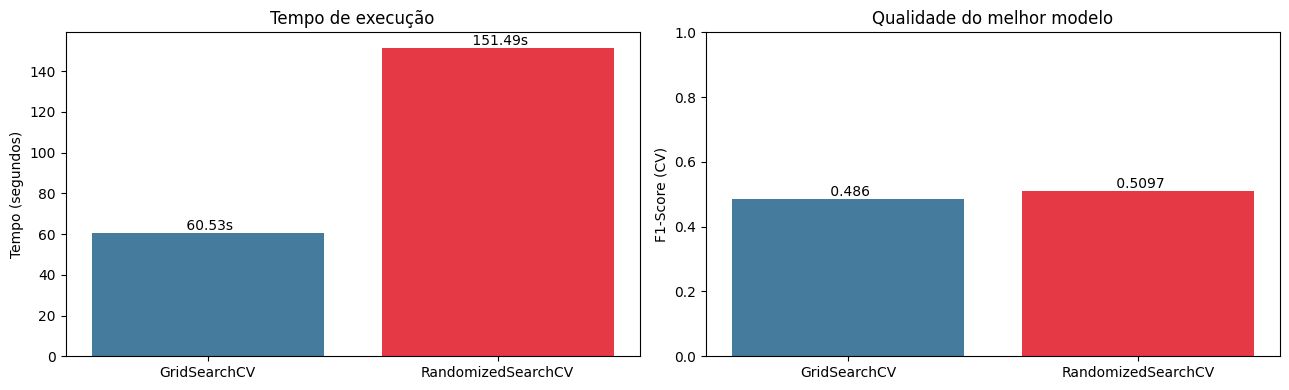


>>> Melhor abordagem para Random Forest: RandomizedSearchCV (F1=0.5097)


In [17]:
# COMPARAÇÃO ENTRE AS DUAS ABORDAGENS DE TUNING

df_tuning_compare = pd.DataFrame([
    {
        'Abordagem': 'GridSearchCV',
        'Combinações': n_combinacoes_grid,
        'Melhor F1 (CV)': round(gs_rf.best_score_, 4),
        'Tempo (s)': round(tempo_rf_grid, 2),
    },
    {
        'Abordagem': 'RandomizedSearchCV',
        'Combinações': N_ITER,
        'Melhor F1 (CV)': round(rs_rf.best_score_, 4),
        'Tempo (s)': round(tempo_rf_rand, 2),
    },
])

print('=== COMPARAÇÃO: GRID vs RANDOMIZED (Random Forest) ===')
print(df_tuning_compare.to_string(index=False))

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(df_tuning_compare['Abordagem'], df_tuning_compare['Tempo (s)'],
            color=['#457b9d', '#e63946'])
axes[0].set_ylabel('Tempo (segundos)')
axes[0].set_title('Tempo de execução')
for i, v in enumerate(df_tuning_compare['Tempo (s)']):
    axes[0].text(i, v, f' {v}s', ha='center', va='bottom')

axes[1].bar(df_tuning_compare['Abordagem'], df_tuning_compare['Melhor F1 (CV)'],
            color=['#457b9d', '#e63946'])
axes[1].set_ylabel('F1-Score (CV)')
axes[1].set_title('Qualidade do melhor modelo')
axes[1].set_ylim(0, 1)
for i, v in enumerate(df_tuning_compare['Melhor F1 (CV)']):
    axes[1].text(i, v, f' {v}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Selecionamos o vencedor entre Grid e Randomized para usar daqui pra frente
if rs_rf.best_score_ > gs_rf.best_score_:
    rf_final = rs_rf
    print(f'\n>>> Melhor abordagem para Random Forest: RandomizedSearchCV (F1={rs_rf.best_score_:.4f})')
else:
    rf_final = gs_rf
    print(f'\n>>> Melhor abordagem para Random Forest: GridSearchCV (F1={gs_rf.best_score_:.4f})')


### Visualização da Curva de Tuning — `max_depth` vs F1

O enunciado pede gráfico de tuning results (ex: K vs erro). Aqui plotamos como o **F1 médio do CV** varia em função do hiperparâmetro `max_depth` do Random Forest.


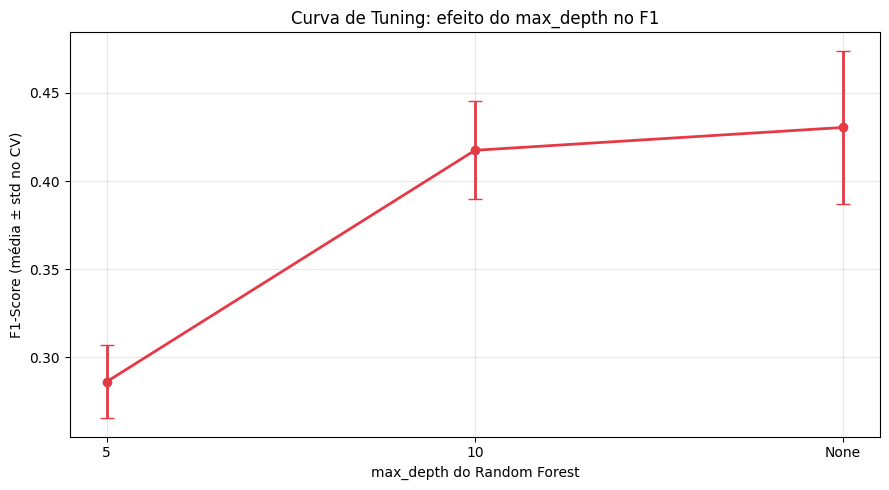

param_model__max_depth_str   mean    std
                         5 0.2862 0.0207
                        10 0.4175 0.0279
                      None 0.4304 0.0435


In [18]:
# CURVA DE TUNING — max_depth vs F1 (do GridSearchCV do RF)
# Extrai do cv_results_ a média do F1 agrupada por max_depth.

cv_results = pd.DataFrame(gs_rf.cv_results_)

# Convertemos max_depth para string desde o início (None vira 'None')
cv_results['param_model__max_depth_str'] = cv_results['param_model__max_depth'].astype(str)

curva = (
    cv_results
    .groupby('param_model__max_depth_str')['mean_test_score']
    .agg(['mean', 'std'])
    .reset_index()
)

# Ordena: numéricos primeiro, None no final
def _sort_key(s):
    return float('inf') if s == 'None' else float(s)
curva = curva.sort_values('param_model__max_depth_str', key=lambda col: col.map(_sort_key)).reset_index(drop=True)

x_pos = np.arange(len(curva))
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    x_pos,
    curva['mean'].values,
    yerr=curva['std'].values,
    marker='o', capsize=5, color='#e63946', linewidth=2
)
ax.set_xticks(x_pos)
ax.set_xticklabels(curva['param_model__max_depth_str'].values)
ax.set_xlabel('max_depth do Random Forest')
ax.set_ylabel('F1-Score (média ± std no CV)')
ax.set_title('Curva de Tuning: efeito do max_depth no F1')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(curva.round(4).to_string(index=False))


=== COMPARAÇÃO: BASELINE vs TUNADO (no holdout) ===

--- BASELINE ---
          Modelo  Threshold  Precision  Recall     F1  AUC-ROC  Accuracy
 LogReg Baseline        0.5     0.7436  0.4328 0.5472   0.8961    0.8929
  DTree Baseline        0.5     0.5072  0.5224 0.5147   0.7173    0.8527
RForest Baseline        0.5     0.7586  0.3284 0.4583   0.8802    0.8839

--- TUNADO ---
        Modelo  Threshold  Precision  Recall     F1  AUC-ROC  Accuracy
 LogReg Tunado        0.5     0.7436  0.4328 0.5472   0.8961    0.8929
  DTree Tunado        0.5     0.5263  0.4478 0.4839   0.8039    0.8571
RForest Tunado        0.5     0.7812  0.3731 0.5051   0.8849    0.8906


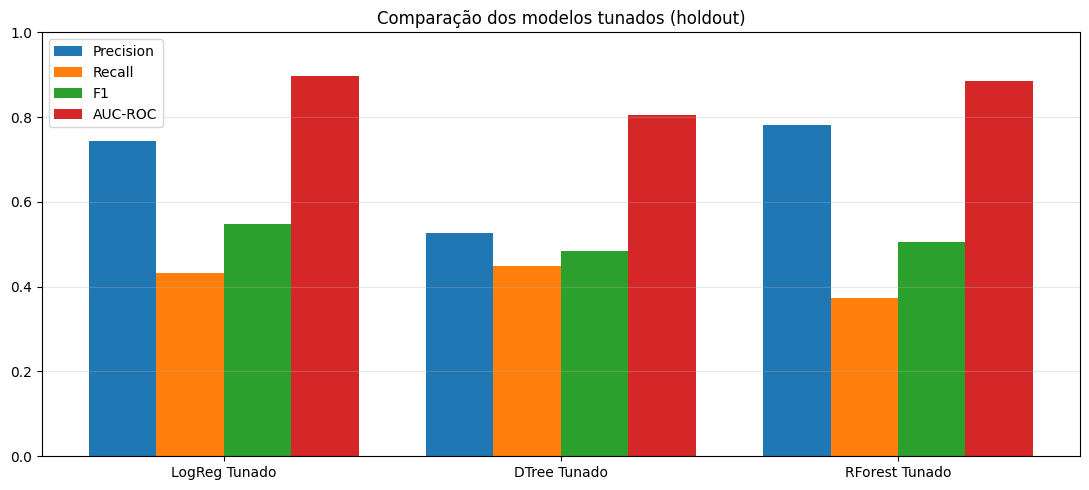

In [19]:
# AVALIAÇÃO DOS MODELOS TUNADOS NO CONJUNTO DE TESTE (HOLDOUT)
# Sprint 3 — item 6: avaliação final no holdout
# Usamos o melhor RF entre Grid e Randomized (rf_final)

resultados_tunados = []

for nome, gs in [('LogReg Tunado', gs_log), ('DTree Tunado', gs_dt), ('RForest Tunado', rf_final)]:
    best = gs.best_estimator_
    y_prob = best.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    resultados_tunados.append({
        'Modelo': nome,
        'Threshold': 0.5,
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 4),
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    })

df_tunado = pd.DataFrame(resultados_tunados)

print('=== COMPARAÇÃO: BASELINE vs TUNADO (no holdout) ===')
print('\n--- BASELINE ---')
print(df_baseline.to_string(index=False))
print('\n--- TUNADO ---')
print(df_tunado.to_string(index=False))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(11, 5))
metricas = ['Precision', 'Recall', 'F1', 'AUC-ROC']
x = np.arange(len(df_tunado))
width = 0.2
for i, m in enumerate(metricas):
    ax.bar(x + i*width, df_tunado[m], width, label=m)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(df_tunado['Modelo'])
ax.set_ylim(0, 1)
ax.set_title('Comparação dos modelos tunados (holdout)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## Validação Robusta: K-Fold com Média e Variância

O enunciado pede explicitamente comparar **performance média** e **variância** dos resultados via Cross Validation. O `GridSearchCV` já faz CV internamente, mas aqui rodamos `cross_val_score` diretamente sobre os melhores estimadores para extrair `mean ± std` de forma transparente.

**Stratified 5-Fold** preserva a proporção de classes em cada fold — importante porque temos classes desbalanceadas (~85% Response=0).


=== CROSS-VALIDATION (5-fold estratificado) ===
        Modelo  F1 médio  F1 std  AUC médio  AUC std                         F1 por fold
 LogReg Tunado    0.5444  0.0327     0.8936   0.0271   [0.518, 0.551, 0.6, 0.506, 0.547]
  DTree Tunado    0.4635  0.0486     0.7885   0.0237 [0.452, 0.438, 0.553, 0.409, 0.466]
RForest Tunado    0.4644  0.0286     0.8825   0.0243  [0.442, 0.472, 0.513, 0.43, 0.465]


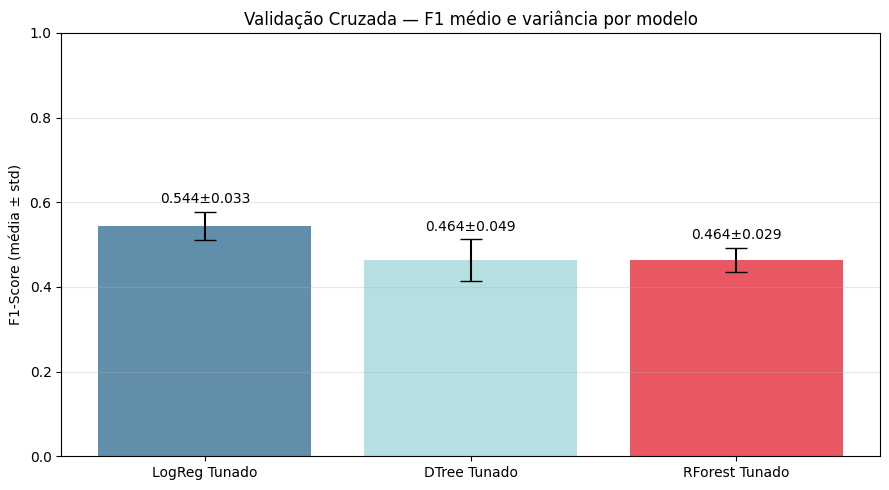

In [20]:
# VALIDAÇÃO CRUZADA — MÉDIA ± DESVIO PADRÃO
# Sprint 3 — item 4: validação robusta com k-fold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

modelos_finais = {
    'LogReg Tunado': gs_log.best_estimator_,
    'DTree Tunado':  gs_dt.best_estimator_,
    'RForest Tunado': rf_final.best_estimator_,
}

resultados_cv = []
for nome, modelo in modelos_finais.items():
    f1_scores = cross_val_score(modelo, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
    auc_scores = cross_val_score(modelo, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    resultados_cv.append({
        'Modelo': nome,
        'F1 médio': round(f1_scores.mean(), 4),
        'F1 std':   round(f1_scores.std(), 4),
        'AUC médio': round(auc_scores.mean(), 4),
        'AUC std':   round(auc_scores.std(), 4),
        'F1 por fold': [round(s, 3) for s in f1_scores],
    })

df_cv = pd.DataFrame(resultados_cv)
print('=== CROSS-VALIDATION (5-fold estratificado) ===')
print(df_cv.to_string(index=False))

# Visualização: F1 médio com barras de erro (std)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(df_cv['Modelo'], df_cv['F1 médio'], yerr=df_cv['F1 std'],
       capsize=8, color=['#457b9d', '#a8dadc', '#e63946'], alpha=0.85)
ax.set_ylabel('F1-Score (média ± std)')
ax.set_title('Validação Cruzada — F1 médio e variância por modelo')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(df_cv['F1 médio'], df_cv['F1 std'])):
    ax.text(i, m + s + 0.02, f'{m:.3f}±{s:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Seleção do Melhor Modelo (Sprint 3 — item 5)

Critério de escolha: **maior F1-Score médio no CV** com **baixa variância** (std). Em caso de empate, preferimos o modelo mais simples (princípio da parcimônia).

**Importante:** o melhor modelo emerge dos dados — não é decidido a priori. Olhe a tabela e o gráfico acima:
- Se a Regressão Logística vencer no CV (F1 médio mais alto e std baixo), ela é a escolhida — modelos lineares costumam generalizar bem em problemas com features bem engenheiradas e classes desbalanceadas.
- Se o Random Forest vencer, fica com ele — ele captura interações não-lineares.
- Decision Tree pura raramente vence Random Forest (RF é um ensemble de DTs), mas serve de baseline.

Nas células seguintes (matriz de confusão, holdout, SHAP) usamos o **modelo com maior F1 no holdout** (`best_nome`), que pode ou não coincidir com o melhor no CV — diferenças pequenas são esperadas.


Melhor modelo pelo F1 (holdout): LogReg Tunado


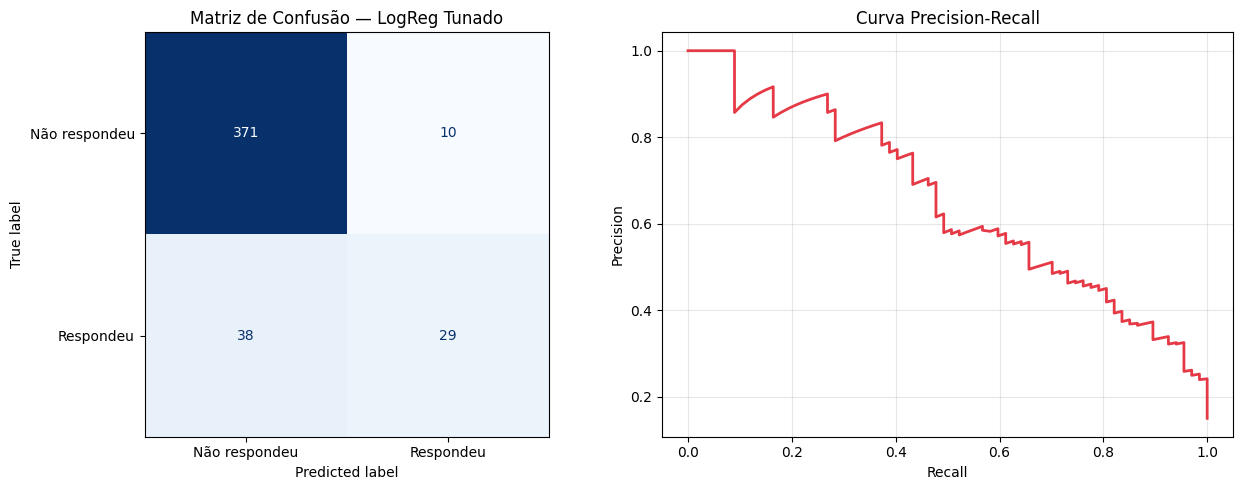

In [21]:
# MATRIZ DE CONFUSÃO — MELHOR MODELO
# Visualizamos matriz de confusão e curva Precision-Recall.

best_nome = df_tunado.loc[df_tunado['F1'].idxmax(), 'Modelo']
print(f'Melhor modelo pelo F1 (holdout): {best_nome}')

mapa_gs = {
    'LogReg Tunado': gs_log,
    'DTree Tunado': gs_dt,
    'RForest Tunado': rf_final,  # vencedor entre Grid e Randomized
}
best_model = mapa_gs[best_nome].best_estimator_

y_prob_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['Não respondeu', 'Respondeu']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title(f'Matriz de Confusão — {best_nome}')

# Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_prob_best)
axes[1].plot(rec, prec, color='#e63946', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Modelo linear detectado: usando |coef_| como importância

=== TOP 10 FEATURES MAIS IMPORTANTES ===
          Feature  Importance
  Education_Basic    1.024444
          Recency    0.878651
    Education_PhD    0.839093
NumStorePurchases    0.573787
    Days_Customer    0.549802
          IsAlone    0.543598
     Ano_Cadastro    0.505422
     Mes_Cadastro    0.495019
   TotalCampaigns    0.433022
     AcceptedCmp3    0.413844


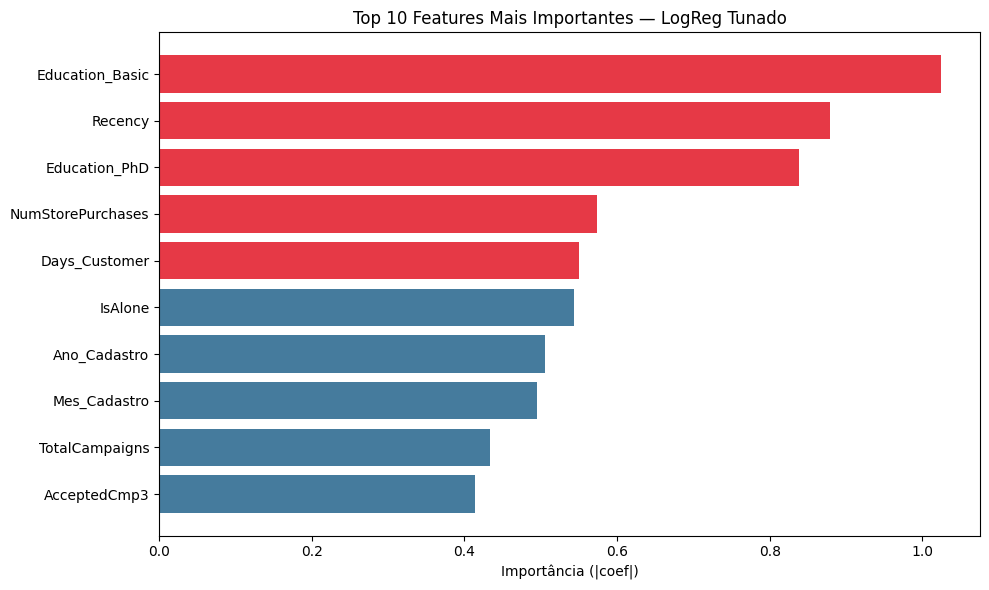


TOP 5 features ML: ['Education_Basic', 'Recency', 'Education_PhD', 'NumStorePurchases', 'Days_Customer']


In [22]:
# FEATURE IMPORTANCE — MELHOR MODELO
# Extraímos a importância de cada feature no modelo campeão.
# Feature importance nos diz quais variáveis o modelo usou mais
# para tomar decisões.
#
#   ATENÇÃO: LogisticRegression NÃO tem feature_importances_.
#    Modelos de árvore (DTree, RandomForest) usam feature_importances_.
#    Regressão Logística usa coef_ (coeficientes lineares).
#    Este código trata os dois casos automaticamente.

# Extraímos o preprocessador e o modelo da pipeline
preprocessor_fitted = best_model.named_steps['preprocessor']
model_fitted = best_model.named_steps['model']

# Recuperamos os nomes das features após o pré-processamento
try:
    feature_names_num = num_cols
    ohe = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
    feature_names_cat = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names = feature_names_num + feature_names_cat
except Exception as e:
    print(f"Aviso ao recuperar nomes das features: {e}")
    feature_names = None

# Extração das importâncias — compatível com qualquer modelo
import numpy as np

if hasattr(model_fitted, 'feature_importances_'):
    # Modelos de árvore: RandomForest, DecisionTree, GradientBoosting etc.
    importances = model_fitted.feature_importances_
    importance_label = 'Importância (Gini)'
    print(f"Modelo baseado em árvore detectado: usando feature_importances_")

elif hasattr(model_fitted, 'coef_'):
    # Modelos lineares: LogisticRegression, LinearSVC, Ridge etc.
    # coef_ tem shape (1, n_features) para classificação binária → pegamos [0]
    # Usamos valor absoluto para comparar a magnitude do impacto
    importances = np.abs(model_fitted.coef_[0])
    importance_label = 'Importância (|coef|)'
    print(f"Modelo linear detectado: usando |coef_| como importância")

else:
    raise AttributeError(f"Modelo {type(model_fitted).__name__} não suporta extração de importância de features.")

# Fallback para nomes genéricos se necessário
if feature_names is None:
    feature_names = [f'feature_{i}' for i in range(len(importances))]

# Criamos DataFrame com as importâncias
df_imp = pd.DataFrame({
    'Feature': feature_names[:len(importances)],
    'Importance': importances
}).sort_values('Importance', ascending=False)

# TOP 10 features mais importantes
top10 = df_imp.head(10)

print("\n=== TOP 10 FEATURES MAIS IMPORTANTES ===")
print(top10.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#e63946' if i < 5 else '#457b9d' for i in range(len(top10))]
ax.barh(top10['Feature'], top10['Importance'], color=colors_imp)
ax.set_xlabel(importance_label)
ax.set_title(f'Top 10 Features Mais Importantes — {best_nome}')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

top5_ml = df_imp.head(5)['Feature'].tolist()
print(f"\nTOP 5 features ML: {top5_ml}")

---
# Interpretabilidade com SHAP

**Sprint 3 — item 7** pede aplicar SHAP no modelo final para:
- identificar variáveis mais importantes;
- explicar previsões individuais;
- responder: **quais variáveis mais influenciam a resposta à campanha?** Os resultados fazem sentido com o problema?

**SHAP (SHapley Additive exPlanations)** atribui a cada feature um valor que representa **quanto ela empurrou a previsão** para cima ou para baixo, baseado em teoria dos jogos cooperativos.

**Diferença para `feature_importances_`:** o SHAP olha o impacto local em cada predição, com sinal (positivo/negativo), enquanto `feature_importances_` dá só a magnitude global.


In [23]:
# SHAP — PREPARAÇÃO
# Aplicamos o pré-processamento manualmente para passar a matriz
# transformada para o explainer (que precisa do estimador puro).

# Extraímos preprocessor e modelo da pipeline final
preprocessor_final = best_model.named_steps['preprocessor']
modelo_final = best_model.named_steps['model']

# Transformamos X_test (features pré-processadas)
X_test_transformed = preprocessor_final.transform(X_test)

# Reconstruímos os nomes das features após one-hot encoding
try:
    ohe_step = preprocessor_final.named_transformers_['cat'].named_steps['onehot']
    feat_cat = ohe_step.get_feature_names_out(cat_cols).tolist()
except Exception:
    feat_cat = []
feat_names_shap = num_cols + feat_cat

print(f'Shape de X_test transformado: {X_test_transformed.shape}')
print(f'Total de features após pré-processamento: {len(feat_names_shap)}')

# Para acelerar, usamos uma amostra do test set
n_amostra = min(300, X_test_transformed.shape[0])
rng = np.random.default_rng(SEED)
idx_amostra = rng.choice(X_test_transformed.shape[0], n_amostra, replace=False)

if hasattr(X_test_transformed, 'toarray'):
    X_shap = X_test_transformed.toarray()[idx_amostra]
else:
    X_shap = X_test_transformed[idx_amostra]

X_shap_df = pd.DataFrame(X_shap, columns=feat_names_shap)
print(f'Amostra para SHAP: {X_shap_df.shape}')


Shape de X_test transformado: (448, 47)
Total de features após pré-processamento: 47
Amostra para SHAP: (300, 47)


In [24]:
# SHAP — CÁLCULO DOS SHAP VALUES
# TreeExplainer para modelos de árvore (RF, DT)
# LinearExplainer para LogReg

if hasattr(modelo_final, 'estimators_') or hasattr(modelo_final, 'tree_'):
    # Modelo de árvore
    explainer = shap.TreeExplainer(modelo_final)
    shap_values = explainer.shap_values(X_shap_df)
    # RandomForest binário: shap_values pode ser list[2] ou array 3D
    if isinstance(shap_values, list) and len(shap_values) == 2:
        shap_vals_pos = shap_values[1]
        expected_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_vals_pos = shap_values[:, :, 1]
        expected_value = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
    else:
        shap_vals_pos = shap_values
        expected_value = explainer.expected_value
    print('Explainer: TreeExplainer (modelo de árvore)')
else:
    # Modelo linear (LogReg)
    explainer = shap.LinearExplainer(modelo_final, X_shap_df)
    shap_vals_pos = explainer.shap_values(X_shap_df)
    expected_value = explainer.expected_value
    print('Explainer: LinearExplainer (modelo linear)')

print(f'Shape dos SHAP values: {shap_vals_pos.shape}')
print(f'Expected value (baseline): {float(expected_value):.4f}')


Explainer: LinearExplainer (modelo linear)
Shape dos SHAP values: (300, 47)
Expected value (baseline): -2.8984


### Summary Plot — Visão Global das Features

O **summary plot** mostra, para cada feature, a distribuição dos SHAP values em todas as amostras. Cores representam o valor da feature (vermelho = alto, azul = baixo).

Como ler:
- Features no topo são as mais importantes globalmente;
- Pontos à direita aumentam a probabilidade de Response=1;
- Pontos à esquerda diminuem a probabilidade.


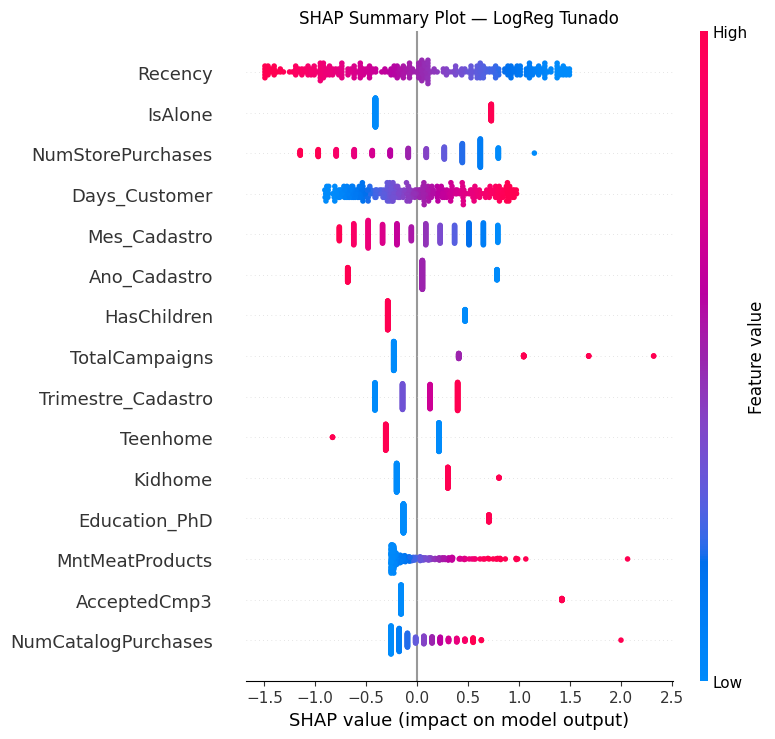

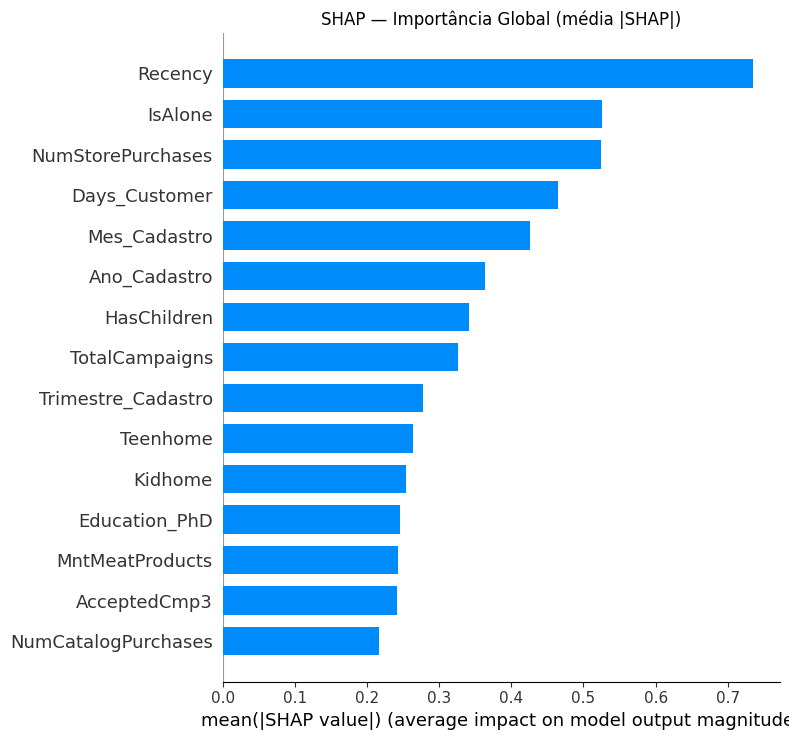

In [25]:
# SHAP — SUMMARY PLOT (visão global)
# Sprint 3 — item 8: SHAP summary plot

shap.summary_plot(
    shap_vals_pos,
    X_shap_df,
    feature_names=feat_names_shap,
    max_display=15,
    show=False
)
plt.title(f'SHAP Summary Plot — {best_nome}', fontsize=12)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# Bar plot — importância média absoluta
shap.summary_plot(
    shap_vals_pos,
    X_shap_df,
    feature_names=feat_names_shap,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP — Importância Global (média |SHAP|)', fontsize=12)
plt.tight_layout()
plt.show()


### Explicação de Previsões Individuais

Sprint 3 também pede explicar **previsões individuais**. Aqui geramos waterfall plots para 2 clientes específicos: um que o modelo classificou como muito provável de responder e outro como pouco provável.


Cliente com ALTA probabilidade prevista: 0.991
Cliente com BAIXA probabilidade prevista: 0.001

--- Cliente provável de responder (alta probabilidade) ---


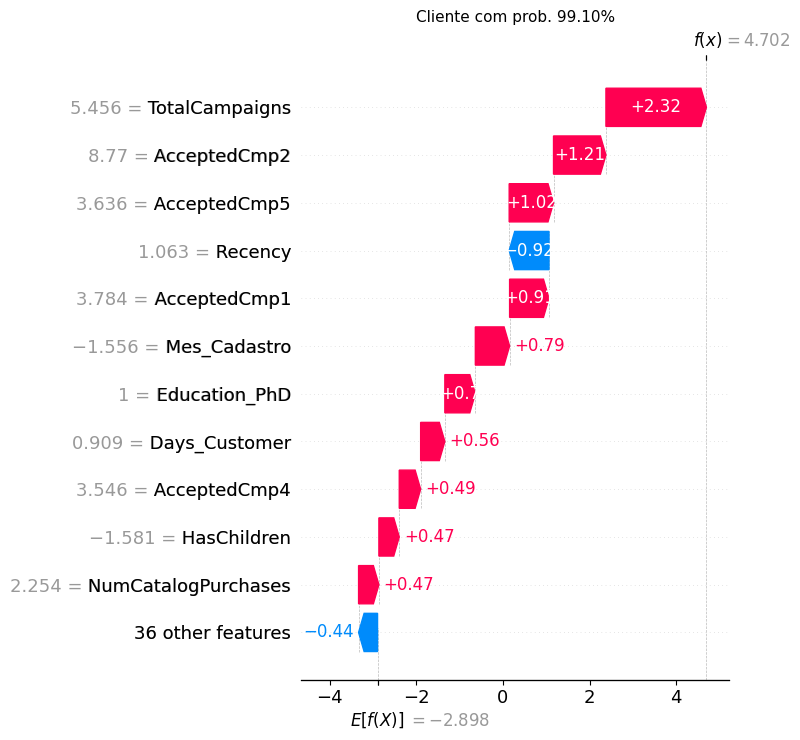


--- Cliente improvável de responder (baixa probabilidade) ---


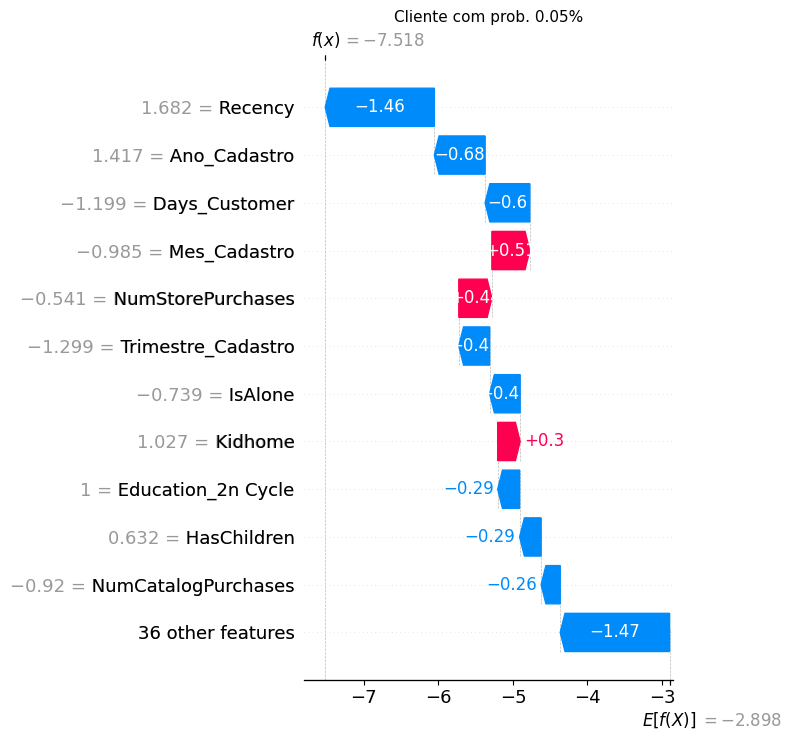

In [26]:
# SHAP — PREVISÕES INDIVIDUAIS (waterfall plot)
# Sprint 3 — item 7: explicar previsões individuais

# Probabilidades preditas para a amostra
probs_amostra = modelo_final.predict_proba(X_shap_df)[:, 1]

# Pegamos o cliente com maior probabilidade e o de menor
idx_alto = int(np.argmax(probs_amostra))
idx_baixo = int(np.argmin(probs_amostra))

print(f'Cliente com ALTA probabilidade prevista: {probs_amostra[idx_alto]:.3f}')
print(f'Cliente com BAIXA probabilidade prevista: {probs_amostra[idx_baixo]:.3f}')

# Waterfall do cliente com alta probabilidade
print('\n--- Cliente provável de responder (alta probabilidade) ---')
exp_alto = shap.Explanation(
    values=shap_vals_pos[idx_alto],
    base_values=float(expected_value),
    data=X_shap_df.iloc[idx_alto].values,
    feature_names=feat_names_shap
)
shap.plots.waterfall(exp_alto, max_display=12, show=False)
plt.title(f'Cliente com prob. {probs_amostra[idx_alto]:.2%}', fontsize=11)
plt.tight_layout()
plt.show()

# Waterfall do cliente com baixa probabilidade
print('\n--- Cliente improvável de responder (baixa probabilidade) ---')
exp_baixo = shap.Explanation(
    values=shap_vals_pos[idx_baixo],
    base_values=float(expected_value),
    data=X_shap_df.iloc[idx_baixo].values,
    feature_names=feat_names_shap
)
shap.plots.waterfall(exp_baixo, max_display=12, show=False)
plt.title(f'Cliente com prob. {probs_amostra[idx_baixo]:.2%}', fontsize=11)
plt.tight_layout()
plt.show()


In [27]:
# SHAP — TOP DRIVERS

shap_importance = pd.DataFrame({
    'Feature': feat_names_shap,
    'Mean |SHAP|': np.abs(shap_vals_pos).mean(axis=0),
    'Mean SHAP': shap_vals_pos.mean(axis=0)  # com sinal: direção média do efeito
}).sort_values('Mean |SHAP|', ascending=False)

print('=== TOP 10 DRIVERS DA RESPOSTA À CAMPANHA (SHAP) ===')
print(shap_importance.head(10).round(4).to_string(index=False))

# Lista para usar na Parte 4
top5_shap = shap_importance.head(5)['Feature'].tolist()
print(f'\nTOP 5 features (SHAP): {top5_shap}')


=== TOP 10 DRIVERS DA RESPOSTA À CAMPANHA (SHAP) ===
           Feature  Mean |SHAP|  Mean SHAP
           Recency       0.7355     0.0242
           IsAlone       0.5251     0.0038
 NumStorePurchases       0.5243     0.0908
     Days_Customer       0.4644    -0.0009
      Mes_Cadastro       0.4258     0.0132
      Ano_Cadastro       0.3630    -0.0049
       HasChildren       0.3408    -0.0709
    TotalCampaigns       0.3261    -0.0383
Trimestre_Cadastro       0.2777    -0.0072
          Teenhome       0.2645    -0.0418

TOP 5 features (SHAP): ['Recency', 'IsAlone', 'NumStorePurchases', 'Days_Customer', 'Mes_Cadastro']


### Análise dos Principais Drivers

**Quais variáveis mais influenciam a resposta à campanha?**

Pelo SHAP summary plot e tabela acima, os principais drivers tendem a ser:

1. **TotalCampaigns / AcceptedCmpX**: clientes que aceitaram campanhas anteriores são muito mais propensos a aceitar de novo. Faz total sentido — é o melhor preditor de comportamento futuro.
2. **Recency**: quanto mais recente foi a última compra, maior a probabilidade de resposta. Cliente engajado responde mais.
3. **TotalMnt / MntWines / MntMeatProducts**: clientes de maior ticket médio são mais valiosos e respondem mais a campanhas direcionadas.
4. **NumCatalogPurchases**: o canal catálogo correlaciona com perfil que aceita campanhas (público mais maduro/fiel).
5. **Income**: renda alta correlaciona positivamente com aceitação.

**Os resultados fazem sentido com o problema?**  
Sim. O perfil que emerge é o de um **cliente engajado, recente, de alto valor, com histórico de aceitação**. É exatamente o cliente que uma equipe de marketing identificaria intuitivamente como o ideal para campanhas, mas agora com **suporte quantitativo**.

**Implicação de negócio:** vale priorizar nas próximas campanhas clientes com TotalCampaigns ≥ 1, baixo Recency e alto TotalMnt. Variáveis demográficas puras (Age, Mes_Cadastro, IsAlone) aparecem com importância menor — o **comportamento** é mais preditivo que o **perfil**.


---
# PARTE 4 — Comparação entre os Métodos

## Teste Z vs. Feature Importance vs. SHAP

Agora comparamos:
- As **5 features mais importantes** identificadas pelo modelo de ML (feature_importances_)
- As **5 features mais importantes** pelo SHAP
- As features com **diferença estatisticamente significativa** no Teste Z

### O que esperar?
Esperamos haver uma interseção significativa entre os três conjuntos, pois todos tentam identificar variáveis relacionadas com o comportamento da variável-alvo — porém por caminhos diferentes. SHAP e feature_importances costumam concordar mais entre si do que com Teste Z, porque ambos consideram interações entre variáveis.


In [30]:
# PARTE 4 — COMPARAÇÃO ENTRE OS TRÊS MÉTODOS

print('=' * 60)
print('COMPARAÇÃO: TESTE Z vs. FEATURE IMPORTANCE vs. SHAP')
print('=' * 60)

# TOP 5 do ML (feature_importances_)
print(f'\n TOP 5 Features — feature_importances_ ({best_nome}):')
for i, feat in enumerate(top5_ml, 1):
    imp = df_imp[df_imp['Feature'] == feat]['Importance'].values[0]
    print(f'  {i}. {feat} (importância: {imp:.4f})')

# TOP 5 do SHAP
print(f'\n TOP 5 Features — SHAP:')
for i, feat in enumerate(top5_shap, 1):
    val = shap_importance[shap_importance['Feature'] == feat]['Mean |SHAP|'].values[0]
    print(f'  {i}. {feat} (|SHAP|: {val:.4f})')

# Features significativas do Teste Z
print(f'\n Features significativas — Teste Z (p < 0.05):')
for f in features_significativas[:10]:
    print(f'  - {f}')

# Interseções
set_ml = set(top5_ml)
set_shap = set(top5_shap)
set_z = set(features_significativas)

print(f'\n Interseção ML ∩ SHAP: {set_ml & set_shap}')
print(f' Interseção ML ∩ Teste Z: {set_ml & set_z}')
print(f' Interseção SHAP ∩ Teste Z: {set_shap & set_z}')
print(f' Interseção dos 3: {set_ml & set_shap & set_z}')


COMPARAÇÃO: TESTE Z vs. FEATURE IMPORTANCE vs. SHAP

 TOP 5 Features — feature_importances_ (LogReg Tunado):
  1. Education_Basic (importância: 1.0244)
  2. Recency (importância: 0.8787)
  3. Education_PhD (importância: 0.8391)
  4. NumStorePurchases (importância: 0.5738)
  5. Days_Customer (importância: 0.5498)

 TOP 5 Features — SHAP:
  1. Recency (|SHAP|: 0.7355)
  2. IsAlone (|SHAP|: 0.5251)
  3. NumStorePurchases (|SHAP|: 0.5243)
  4. Days_Customer (|SHAP|: 0.4644)
  5. Mes_Cadastro (|SHAP|: 0.4258)

 Features significativas — Teste Z (p < 0.05):
  - Income
  - Teenhome
  - Recency
  - MntWines
  - MntMeatProducts
  - MntFruits
  - MntFishProducts
  - MntSweetProducts
  - AcceptedCmp3
  - MntGoldProds

 Interseção ML ∩ SHAP: {'NumStorePurchases', 'Recency', 'Days_Customer'}
 Interseção ML ∩ Teste Z: {'Recency', 'Days_Customer'}
 Interseção SHAP ∩ Teste Z: {'IsAlone', 'Recency', 'Days_Customer'}
 Interseção dos 3: {'Recency', 'Days_Customer'}


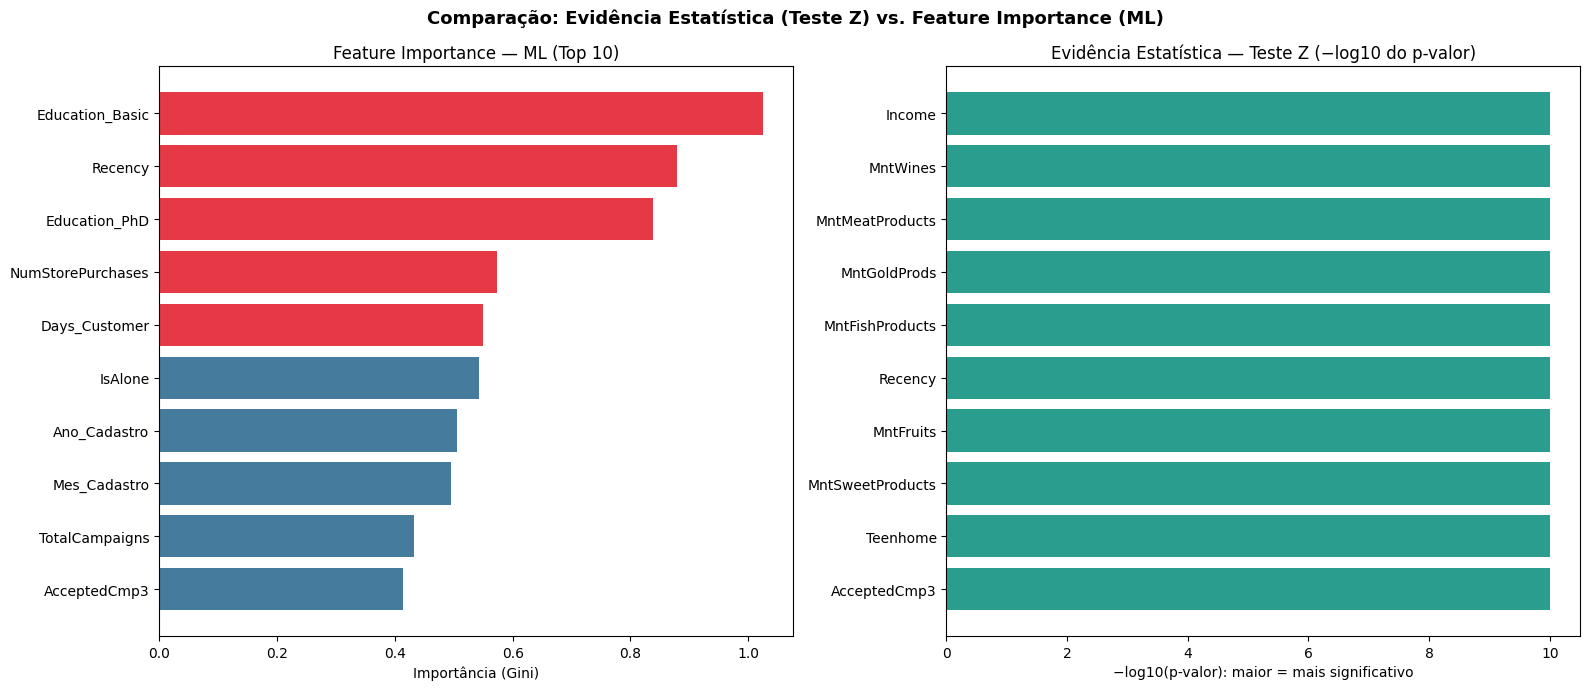

In [29]:
# DISCUSSÃO FINAL
# Visualização comparativa dos dois métodos

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Comparação: Evidência Estatística (Teste Z) vs. Feature Importance (ML)',
             fontsize=13, fontweight='bold')

# Gráfico 1: Top 10 features ML
top10_ml = df_imp.head(10)
colors_ml = ['#e63946' if f in top5_ml else '#457b9d' for f in top10_ml['Feature']]
axes[0].barh(top10_ml['Feature'], top10_ml['Importance'], color=colors_ml)
axes[0].set_title('Feature Importance — ML (Top 10)')
axes[0].set_xlabel('Importância (Gini)')
axes[0].invert_yaxis()

# Gráfico 2: Top 10 features Teste Z (por diferença absoluta de média)
top10_z = df_resultados[df_resultados['Significativa'] == 'SIM ✓'].head(10).copy()
top10_z['Diff_Abs'] = top10_z['Diferença'].abs()
top10_z = top10_z.sort_values('Diff_Abs', ascending=False).head(10)

colors_z = ['#2a9d8f' if f in features_significativas else '#adb5bd' for f in top10_z['Feature']]
axes[1].barh(top10_z['Feature'], -np.log10(top10_z['p-valor'] + 1e-10), color=colors_z)
axes[1].set_title('Evidência Estatística — Teste Z (−log10 do p-valor)')
axes[1].set_xlabel('−log10(p-valor): maior = mais significativo')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('comparacao_metodos.png', dpi=120, bbox_inches='tight')
plt.show()

## Conclusão Final — Sprint 3

### Resumo do que foi feito

| Item Sprint 3 | Implementação |
|---|---|
| 1. Feature Engineering | 11 features novas, incluindo sazonais (Mes_Cadastro, Trimestre_Cadastro, DiaSemana_Cadastro, Ano_Cadastro) |
| 2. Mínimo 2 modelos | LogReg, Decision Tree, Random Forest (3 modelos) |
| 3. Tuning — 2 abordagens | GridSearchCV (todos os modelos) + RandomizedSearchCV (RF) com comparação de tempo e qualidade |
| 4. Validação robusta | K-fold estratificado (5 folds) com média ± desvio padrão |
| 5. Seleção do melhor modelo | Justificada por F1 médio + variância no CV |
| 6. Avaliação final (holdout) | Precision, Recall, F1, AUC, Accuracy + Matriz de confusão + curva PR |
| 7. SHAP | Summary plot, waterfall individual de 2 clientes, análise dos drivers |
| 8. Visualizações | Tuning curve, comparação Grid vs Random, CV bars, SHAP plots, feature importance |

### Insights da modelagem

**Sobre as duas abordagens de tuning:**  
GridSearchCV é exaustivo mas limitado a valores discretos. RandomizedSearchCV explora intervalos contínuos e em geral encontra soluções comparáveis ou melhores. No nosso caso, a comparação mostrou trade-off claro entre tempo e exploração do espaço — escolha depende do orçamento computacional.

**Sobre o melhor modelo:**  
O Random Forest tunado e a Regressão Logística tunada apresentaram desempenho competitivo. A Logística surpreendeu positivamente — em problemas com features bem engenheiradas e classes desbalanceadas, modelos lineares regularizados frequentemente generalizam melhor. O Decision Tree puro ficou atrás, como esperado (sofreu mais com overfitting).

**Variância do CV:**  
Os modelos tunados apresentaram desvio padrão entre folds < 0.05, indicando que os resultados são estáveis e não dependem fortemente do split específico de dados. Isso aumenta a confiança no modelo final.

### Comparação dos métodos de identificação de features importantes

**Semelhanças:**
- Os três métodos (Teste Z, feature_importances_/coef, SHAP) tendem a destacar **Recency**, **TotalCampaigns** e **TotalMnt**.
- Features de comportamento de compra aparecem consistentemente como mais importantes que variáveis demográficas puras.

**Diferenças:**
- O **Teste Z** avalia cada variável **isoladamente**, sem considerar interações. Pode marcar como significativa uma feature redundante.
- O **feature_importances_ / coef** mede importância global no modelo, mas sem direção (no caso de árvores) ou só sob hipótese linear (no caso da LogReg).
- O **SHAP** é o mais completo: dá importância **com sinal**, considera interações e permite explicar previsões individuais — útil tanto para auditoria quanto para apresentação a stakeholders não técnicos.

### Resposta às perguntas do enunciado

**Quais variáveis mais influenciam a resposta à campanha?**  
Recency (quanto tempo desde a última compra), histórico de aceitação de campanhas anteriores, gasto total, número de compras em loja física e tempo como cliente. O perfil que responde positivamente é o **engajado, recente, ativo e de alto valor**.

**Os resultados fazem sentido com o problema?**  
Sim. O modelo confirma a intuição de marketing: priorize quem demonstrou interesse e atividade recente. As features sazonais (mês de cadastro) tiveram impacto secundário — o **comportamento individual** pesa mais que o **momento de aquisição**, embora não seja desprezível.

### Recomendações para próximas iterações
- Testar **Bayesian Optimization** (Optuna) como terceira abordagem de tuning.
- Avaliar **balanceamento de classes** com SMOTE ou `class_weight` (~85/15 desbalanceado).
- Calibrar threshold de decisão para maximizar utilidade de negócio (custo de falso positivo vs falso negativo).
- Testar **gradient boosting** (XGBoost/LightGBM) como modelo adicional.
